In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from shapely.geometry import Polygon

plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.axisbelow"] = True

RESULTS_DIR = Path("01-RESULTS")
SCENARIO = "with_battery"          # match config.scenario
START_TAG = "04-01_12-00"          # match config.start_time

# Find all duration folders for this scenario+start
pattern = f"multi_ts_{SCENARIO}_{START_TAG}_d*h"  #for minkowski nodal aggregation
#pattern = f"multi_ts_benchmark_{SCENARIO}_{START_TAG}_d*h" #for benchmark nodal aggregation
MODEL_LABEL = "Benchmark" if pattern.startswith("multi_ts_benchmark_") else "Minkowski"
run_dirs = sorted(RESULTS_DIR.glob(pattern),
                  key=lambda p: int(p.name.split("_d")[-1].rstrip("h")))

print(f"Found {len(run_dirs)} duration runs:")
for d in run_dirs:
    print(f"  {d.name}")

Found 4 duration runs:
  multi_ts_with_battery_04-01_12-00_d1h
  multi_ts_with_battery_04-01_12-00_d2h
  multi_ts_with_battery_04-01_12-00_d4h
  multi_ts_with_battery_04-01_12-00_d8h


In [3]:
def load_all(filename: str) -> pd.DataFrame:
    """Concatenate `filename` across all duration folders."""
    dfs = []
    for d in run_dirs:
        f = d / filename
        if not f.exists():
            print(f"  ⚠ missing: {f}")
            continue
        df = pd.read_csv(f)
        # Belt-and-suspenders: derive duration from folder name if column missing
        if "duration_h" not in df.columns:
            df["duration_h"] = int(d.name.split("_d")[-1].rstrip("h"))
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

vertices = load_all("ffor_vertices.csv")
pcc      = load_all("pcc_results_all_directions.csv")
flex     = load_all("flex_results_all_directions.csv")

# Parse types
for df in (pcc, flex):
    df["time"] = pd.to_datetime(df["time"])
flex["bus"] = flex["bus"].astype(int)

print(f"vertices : {len(vertices):>6} rows  ({sorted(vertices['duration_h'].unique())})")
print(f"pcc      : {len(pcc):>6} rows")
print(f"flex     : {len(flex):>6} rows")
vertices.head()

vertices :    128 rows  ([np.int64(1), np.int64(2), np.int64(4), np.int64(8)])
pcc      :    321 rows
flex     :  39804 rows


,direction_id,duration_h,theta_rad,theta_deg,alpha,beta,status,solver_status,solve_attempt,obj_value,P_flex_pcc,Q_flex_pcc
0,0,1,0.000000,0.00,-1.000000,-0.000000,optimal,ok,default,-0.535770,0.535770,0.093036
1,1,1,0.196350,11.25,-0.980785,-0.195090,optimal,ok,default,-0.544108,0.535650,0.096110
2,2,1,0.392699,22.50,-0.923880,-0.382683,optimal,ok,default,-0.535971,0.516716,0.153098
3,3,1,0.589049,33.75,-0.831470,-0.555570,optimal,ok,default,-0.522369,0.479764,0.222221
4,4,1,0.785398,45.00,-0.707107,-0.707107,optimal,ok,default,-0.504066,0.429960,0.282897


In [4]:
status_summary = (
    vertices
    .groupby(["duration_h", "status"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)
print(status_summary)

# List which directions failed for each duration
for d in sorted(vertices["duration_h"].unique()):
    failed = vertices[(vertices["duration_h"] == d) &
                      (vertices["status"] != "optimal")]
    if len(failed):
        print(f"\nd={d}h — failed directions ({len(failed)}):")
        print(failed[["direction_id", "theta_deg", "solver_status"]].to_string(index=False))

status      error  optimal
duration_h                
1               1       31
2               7       25
4              12       20
8              12       20

d=1h — failed directions (1):
 direction_id  theta_deg solver_status
           14      157.5         error

d=2h — failed directions (7):
 direction_id  theta_deg solver_status
            5      56.25         error
            9     101.25         error
           10     112.50         error
           12     135.00         error
           13     146.25         error
           14     157.50         error
           31     348.75         error

d=4h — failed directions (12):
 direction_id  theta_deg solver_status
            4      45.00         error
            9     101.25         error
           10     112.50         error
           11     123.75         error
           12     135.00         error
           13     146.25         error
           14     157.50         error
           15     168.75         error
   

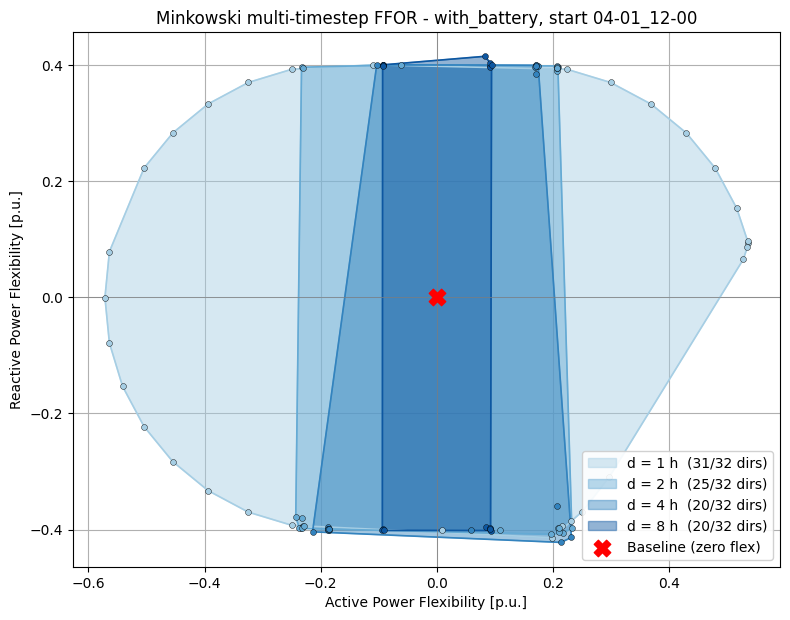

In [19]:
from matplotlib.patches import Polygon as MplPolygon
import matplotlib.cm as cm

fig, ax = plt.subplots(figsize=(8, 8))

durations = sorted(vertices["duration_h"].unique())
# Light → dark blue as duration increases (paper Fig. 6 convention)
colors = cm.Blues(np.linspace(0.35, 0.85, len(durations)))

# Plot LONGEST first so shortest (largest area) ends up on top? No —
# longest is SMALLEST area, so we plot longest LAST to keep it visible inside.
# Actually since shorter durations have LARGER FFORs, plot longest→shortest
# so the small polygons sit visibly inside the larger ones.
for duration_h, color in zip(durations, colors):
    sub = (vertices
           .query("duration_h == @duration_h and status == 'optimal'")
           .sort_values("theta_deg"))

    pts = sub[["P_flex_pcc", "Q_flex_pcc"]].values
    if len(pts) < 3:
        continue

    # Convex hull of the sampled support points = FFOR estimate
    hull = Polygon(pts).convex_hull
    hx, hy = hull.exterior.xy

    ax.fill(hx, hy, color=color, alpha=0.45,
            label=f"d = {duration_h} h  ({len(sub)}/{config_n_dirs if False else 32} dirs)")
    ax.plot(hx, hy, color=color, lw=1.2)
    ax.scatter(pts[:, 0], pts[:, 1], color=color, s=18, zorder=3,
               edgecolors="black", linewidths=0.3)

# Baseline marker (FFOR is centered at origin by definition, paper Sec II-C1)
ax.scatter(0, 0, c="red", s=140, marker="X", zorder=5,
           label="Baseline (zero flex)")

ax.axhline(0, color="gray", lw=0.5)
ax.axvline(0, color="gray", lw=0.5)
ax.set_xlabel("Active Power Flexibility [p.u.]")
ax.set_ylabel("Reactive Power Flexibility [p.u.]")
ax.set_title(f"{MODEL_LABEL} multi-timestep FFOR - {SCENARIO}, start {START_TAG}")
ax.set_aspect("equal")
ax.legend(loc="best", framealpha=0.9)
plt.tight_layout()
fig.savefig(f"01-PLOTS/{MODEL_LABEL}_multi_timestep_ffor_{SCENARIO}_{START_TAG}.svg",
            format="svg", bbox_inches="tight")
plt.show()

 duration_h  P_flex_pos  P_flex_neg  Q_flex_pos  Q_flex_neg
          1    0.535770   -0.571613    0.400457   -0.414083
          2    0.232594   -0.242934    0.400395   -0.408396
          4    0.231861   -0.213998    0.400475   -0.422196
          8    0.094313   -0.093749    0.415086   -0.401747


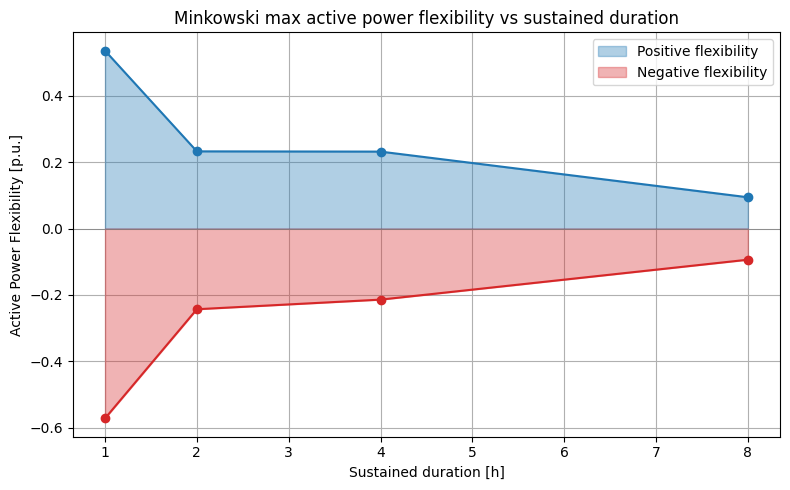

In [18]:
# For each duration, pull the extreme P-flex (positive and negative)
extents = (
    vertices
    .query("status == 'optimal'")
    .groupby("duration_h")
    .agg(P_flex_pos=("P_flex_pcc", "max"),
         P_flex_neg=("P_flex_pcc", "min"),
         Q_flex_pos=("Q_flex_pcc", "max"),
         Q_flex_neg=("Q_flex_pcc", "min"))
    .reset_index()
    .sort_values("duration_h")
)
print(extents.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
ax.fill_between(extents["duration_h"], 0, extents["P_flex_pos"],
                color="C0", alpha=0.35, label="Positive flexibility")
ax.fill_between(extents["duration_h"], extents["P_flex_neg"], 0,
                color="C3", alpha=0.35, label="Negative flexibility")
ax.plot(extents["duration_h"], extents["P_flex_pos"], "o-", color="C0")
ax.plot(extents["duration_h"], extents["P_flex_neg"], "o-", color="C3")
ax.axhline(0, color="gray", lw=0.5)
ax.set_xlabel("Sustained duration [h]")
ax.set_ylabel("Active Power Flexibility [p.u.]")
ax.set_title(f"{MODEL_LABEL} max active power flexibility vs sustained duration")
ax.legend()
plt.tight_layout()

fig.savefig(f"01-PLOTS/{MODEL_LABEL} max active power flexibility vs sustained duration.svg",
            format="svg", bbox_inches="tight")
plt.show()

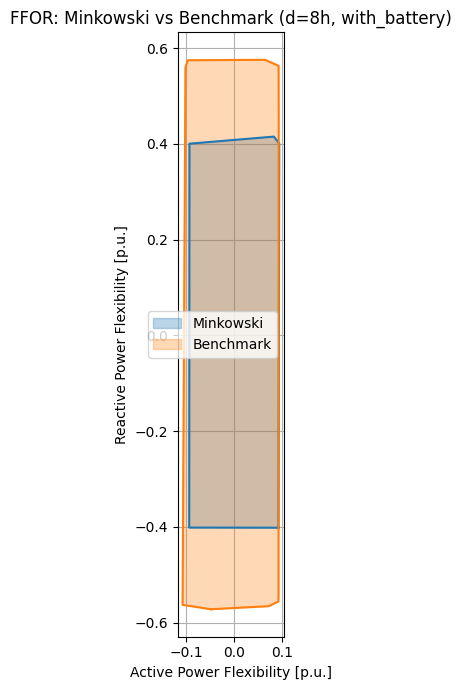

In [17]:
from shapely.geometry import Polygon

def load_vertices(pattern):
    dirs = sorted(RESULTS_DIR.glob(pattern),
                  key=lambda p: int(p.name.split("_d")[-1].rstrip("h")))
    dfs = []
    for d in dirs:
        f = d / "ffor_vertices.csv"
        if not f.exists():
            continue
        df = pd.read_csv(f)
        if "duration_h" not in df.columns:
            df["duration_h"] = int(d.name.split("_d")[-1].rstrip("h"))
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

mink  = load_vertices(f"multi_ts_{SCENARIO}_{START_TAG}_d*h")
bench = load_vertices(f"multi_ts_benchmark_{SCENARIO}_{START_TAG}_d*h")

def hull_xy(df, duration_h):
    sub = df.query("duration_h == @duration_h and status == 'optimal'") \
            .sort_values("theta_deg")
    pts = sub[["P_flex_pcc", "Q_flex_pcc"]].values
    return Polygon(pts).convex_hull.exterior.xy if len(pts) >= 3 else None

DUR = 8 # pick a duration present in both runs
fig, ax = plt.subplots(figsize=(7, 7))
for df, name, c in [(mink, "Minkowski", "C0"), (bench, "Benchmark", "C1")]:
    xy = hull_xy(df, DUR)
    if xy is None:
        continue
    ax.fill(*xy, alpha=0.3, color=c, label=name)
    ax.plot(*xy, color=c, lw=1.5)
#ax.scatter(0, 0, c="red", marker="", s=120, zorder=5, label="Baseline")
ax.set_aspect("equal"); ax.legend()
ax.set_xlabel("Active Power Flexibility [p.u.]")
ax.set_ylabel("Reactive Power Flexibility [p.u.]")
ax.set_title(f"FFOR: Minkowski vs Benchmark (d={DUR}h, {SCENARIO})")
plt.tight_layout(); 
from pathlib import Path
Path("01-PLOTS").mkdir(exist_ok=True)
fig.savefig(f"01-PLOTS/ffor_minsk_vs_benchmark_duration_{DUR}h.svg",
            format="svg", bbox_inches="tight")
plt.show()

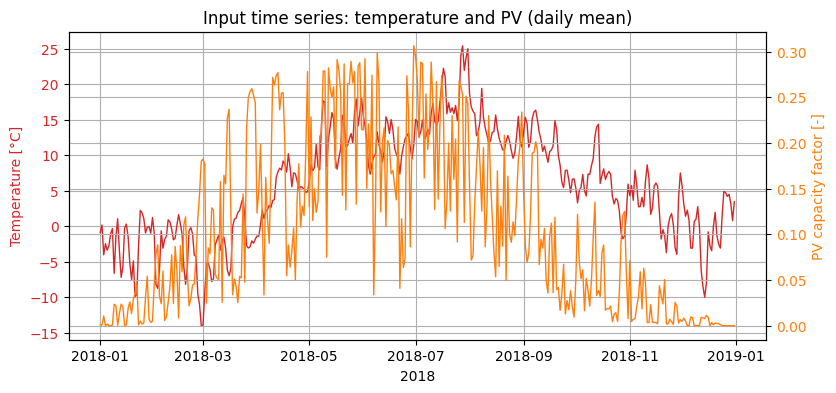

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pv = pd.read_csv("00-INPUT-DATA/PV-DATA/PV_timeseries.csv",
                 parse_dates=["time"], index_col="time")
temp = pd.read_csv("00-INPUT-DATA/TEMP-DATA/TEMP_timeseries.csv",
                   parse_dates=["date"], index_col="date")
temp.index = pd.DatetimeIndex(temp.index).tz_localize(None)

# Daily means smooth the hourly noise into a readable seasonal curve
pv_d = pv["electricity"].resample("D").mean()
temp_d = temp["temperature_2m"].resample("D").mean()

fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.plot(temp_d.index, temp_d.values, color="C3", lw=1, label="Temperature")
ax1.set_ylabel("Temperature [°C]", color="C3")
ax1.tick_params(axis="y", labelcolor="C3")

ax2 = ax1.twinx()
ax2.plot(pv_d.index, pv_d.values, color="C1", lw=1, label="PV capacity factor")
ax2.set_ylabel("PV capacity factor [-]", color="C1")
ax2.tick_params(axis="y", labelcolor="C1")

ax1.set_xlabel("2018")
ax1.set_title("Input time series: temperature and PV (daily mean)")

Path("01-PLOTS").mkdir(exist_ok=True)
fig.savefig("01-PLOTS/input_timeseries.svg", format="svg", bbox_inches="tight")
plt.show()

In [ ]:
from pathlib import Path
import pandas as pd

import matplotlib.pyplot as plt

data_dir = Path("00-INPUT-DATA")
out_dir = Path("01-PLOTS"); out_dir.mkdir(exist_ok=True)

# find candidate node (bus) file
csvs = list(data_dir.rglob("*.csv"))
node_files = [p for p in csvs if any(k in p.name.lower() for k in ("bus", "node"))]
if not node_files:
    raise FileNotFoundError("No bus/node CSV found in 00-INPUT-DATA")

nodes = pd.read_csv(node_files[0])
# detect coordinate columns
coord_cols = None
for xcol, ycol in (("x", "y"), ("lon", "lat"), ("longitude", "latitude"),
                   ("east", "north"), ("long", "lat")):
    if xcol in nodes.columns and ycol in nodes.columns:
        coord_cols = (xcol, ycol); break
if coord_cols is None:
    raise ValueError(f"No coordinate columns found in {node_files[0].name}; expected one of x/y, lon/lat, longitude/latitude, east/north")

xcol, ycol = coord_cols

# try to find edge/line file
edge_files = [p for p in csvs if any(k in p.name.lower() for k in ("line", "branch", "edge", "conn", "branch"))]
edges = None
if edge_files:
    edges = pd.read_csv(edge_files[0])
    # detect from/to columns
    fromcol = next((c for c in edges.columns if c.lower() in ("from_bus","from","fbus","bus_from")), None)
    tocol   = next((c for c in edges.columns if c.lower() in ("to_bus","to","tbus","bus_to")), None)
    if fromcol is None or tocol is None:
        edges = None

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(nodes[xcol], nodes[ycol], s=30, c="C0", zorder=3)
for idx, row in nodes.iterrows():
    ax.text(row[xcol], row[ycol], str(row.get("bus_id", row.get("id", row.get("name", idx)))), fontsize=8, ha="right", va="bottom")

if edges is not None:
    # merge coordinates
    left = edges.merge(nodes.rename(columns={xcol: "x_from", ycol: "y_from"}), left_on=fromcol, right_on=nodes.columns[0], how="left")
    left = left.merge(nodes.rename(columns={xcol: "x_to", ycol: "y_to"}), left_on=tocol, right_on=nodes.columns[0], how="left", suffixes=("_from", "_to"))
    for _, e in left.iterrows():
        if pd.notnull(e.get("x_from")) and pd.notnull(e.get("x_to")):
            ax.plot([e["x_from"], e["x_to"]], [e["y_from"], e["y_to"]], color="gray", lw=0.8, zorder=1)

ax.set_title("Network plot")
ax.set_xlabel(xcol); ax.set_ylabel(ycol)
ax.set_aspect("equal")
plt.tight_layout()
fig.savefig(out_dir / "network_plot.svg", format="svg", bbox_inches="tight")
plt.show()

ValueError: No coordinate columns found in Node.csv; expected one of x/y, lon/lat, longitude/latitude, east/north